In [44]:
import pandas as pd
import numpy as np

# load CSV
df = pd.read_csv("three_noisy_signals.csv")

# select signals
X = df[
    ["signal2_noisy", "signal3_noisy", "signal4_noisy"]
].values

# reshape for SAITS
X = X[np.newaxis, :, :]

print("Shape:", X.shape)
print("Missing values:", np.isnan(X).sum())

Shape: (1, 200, 3)
Missing values: 0


In [45]:
import numpy as np

def spike_to_nan_local(x, window=4, threshold=0.5):
    x = x.copy()

    for i in range(len(x)):
        left = max(0, i-window)
        right = min(len(x), i+window+1)

        local = x[left:right]
        med = np.nanmedian(local)
        mad = np.nanmedian(np.abs(local - med)) + 1e-8

        score = abs(x[i] - med) / mad

        if score > threshold:
            x[i] = np.nan

    return x

In [46]:
df = pd.read_csv("three_noisy_signals.csv")

df["signal2_noisy"] = spike_to_nan_local(df["signal2_noisy"].values)
df["signal3_noisy"] = spike_to_nan_local(df["signal3_noisy"].values)
df["signal4_noisy"] = spike_to_nan_local(df["signal4_noisy"].values)

print(df.isna().sum())

time               0
signal2_clean      0
signal2_noisy    152
signal3_clean      0
signal3_noisy    156
signal4_clean      0
signal4_noisy    156
dtype: int64


In [47]:
X = df[["signal2_noisy", "signal3_noisy", "signal4_noisy"]].values
X = X[np.newaxis, :, :]

print("Missing values:", np.isnan(X).sum())

Missing values: 464


In [48]:
from pypots.imputation import SAITS

model = SAITS(
    n_steps=X.shape[1],      # time points (e.g. 200)
    n_features=X.shape[2],   # number of signals (3)

    n_layers=2,
    d_model=64,
    n_heads=4,
    d_k=16,
    d_v=16,
    d_ffn=128,

    dropout=0.1,
    epochs=20,
    batch_size=8
)

# train
model.fit({"X": X})

# impute missing values
X_imputed = model.impute({"X": X})

print("Imputed shape:", X_imputed.shape)
print("Remaining NaNs:", np.isnan(X_imputed).sum())

2026-04-24 22:00:11 [INFO]: No given device, using default device: cpu
2026-04-24 22:00:11 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2026-04-24 22:00:11 [INFO]: Using customized MAE as the training loss function.
2026-04-24 22:00:11 [INFO]: Using customized MSE as the validation metric function.
2026-04-24 22:00:11 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 134,774
2026-04-24 22:00:11 [INFO]: Epoch 001 - training loss (MAE): 1.4898
2026-04-24 22:00:11 [INFO]: Epoch 002 - training loss (MAE): 1.1957
2026-04-24 22:00:11 [INFO]: Epoch 003 - training loss (MAE): 1.2173
2026-04-24 22:00:11 [INFO]: Epoch 004 - training loss (MAE): 1.1853
2026-04-24 22:00:11 [INFO]: Epoch 005 - training loss (MAE): 1.1245
2026-04-24 22:00:11 [INFO]: Epoch 006 - training loss (MAE): 1.2810
2026-04-24 22:00:11 [INFO]: Epoch 007 - training loss (MAE): 1.2307
2026-04-24 22:00:11 [INFO]: Epoch 008 - training loss (MAE

Imputed shape: (1, 200, 3)
Remaining NaNs: 0


In [40]:
print(df.columns)

Index(['time', 'signal2_clean', 'signal2_noisy', 'signal3_clean',
       'signal3_noisy', 'signal4_clean', 'signal4_noisy'],
      dtype='str')


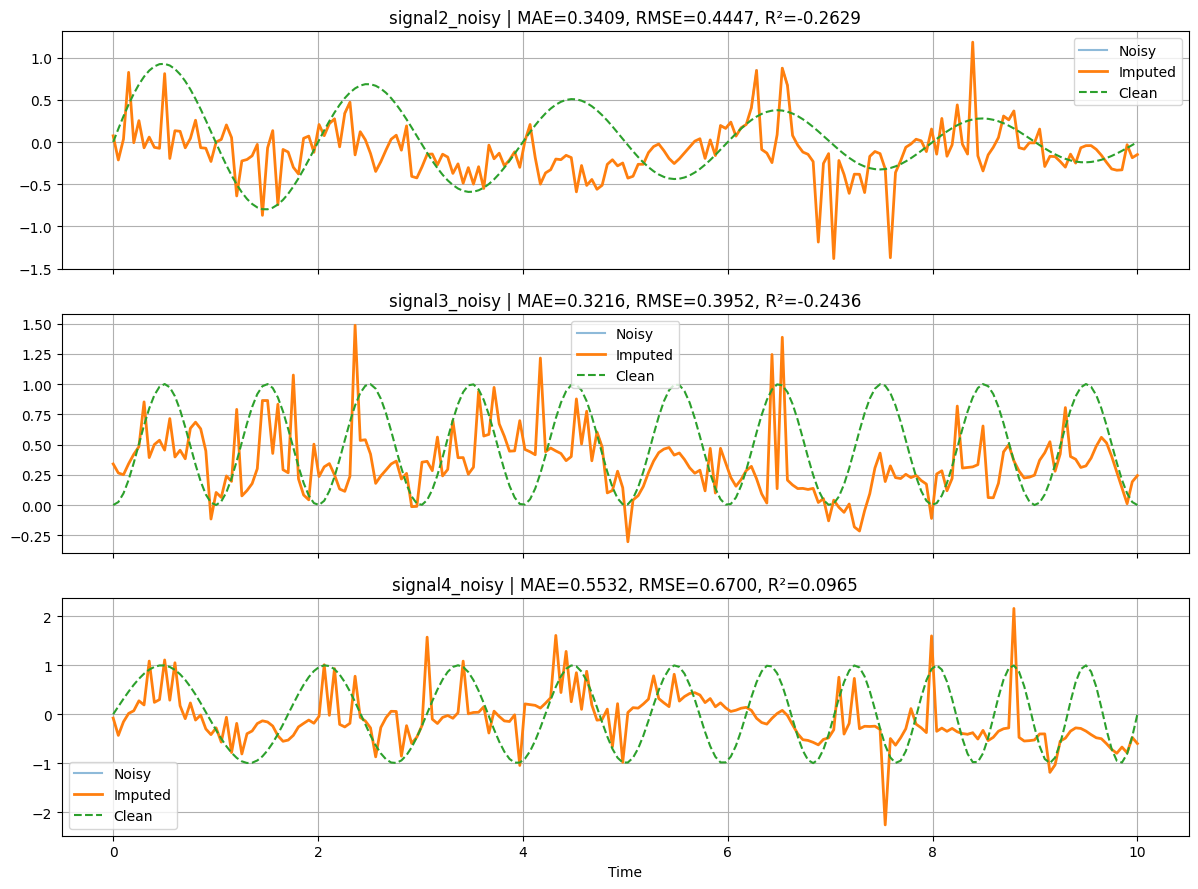

In [49]:
import numpy as np
import matplotlib.pyplot as plt

t = df["time"].values

fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

pairs = [
    ("signal2_clean", "signal2_noisy", 0),
    ("signal3_clean", "signal3_noisy", 1),
    ("signal4_clean", "signal4_noisy", 2),
]

for ax, (clean_col, noisy_col, idx) in zip(axs, pairs):
    clean = df[clean_col].values
    noisy = df[noisy_col].values
    imputed = X_imputed[0, :, idx]

    # error metrics
    mae = np.mean(np.abs(imputed - clean))
    rmse = np.sqrt(np.mean((imputed - clean)**2))

    ss_res = np.sum((clean - imputed)**2)
    ss_tot = np.sum((clean - np.mean(clean))**2)
    r2 = 1 - ss_res / ss_tot

    ax.plot(t, noisy, label="Noisy", alpha=0.5)
    ax.plot(t, imputed, label="Imputed", linewidth=2)
    ax.plot(t, clean, label="Clean", linestyle="--")

    ax.set_title(
        f"{noisy_col} | MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}"
    )
    ax.legend()
    ax.grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()